In [1]:
from pygris import tracts
from pygris.data import get_lodes
from pyproj import CRS
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import geoplot as gplt
import geoplot.crs as gcrs
import mapclassify as mc
from shapely.geometry import Point
from shapely.geometry import MultiPoint
import folium
import geojson
import requests


In [63]:
#step 1 get lodes
va_lodes_od = get_lodes(
    state = "VA",
    year = 2021,
    lodes_type = "od")

va_lodes_od.head()


,index,w_geocode,h_geocode,S000,SA01,SA02,SA03,SE01,SE02,SE03,SI01,SI02,SI03
0,0,510010901011006,510010902023010,1,0,1,0,1,0,0,0,0,1
1,1,510010901011011,510010901011027,1,0,1,0,0,1,0,1,0,0
2,2,510010901011011,510010901011033,1,0,0,1,0,1,0,0,1,0
3,3,510010901011011,510010901011041,1,1,0,0,1,0,0,0,1,0
4,4,510010901011011,510010901021002,1,0,0,1,0,1,0,0,1,0


In [64]:
geocode = (
    va_lodes_od
    .assign(w_tract = va_lodes_od['w_geocode'].str.slice(stop = 11),
            h_tract = va_lodes_od['h_geocode'].str.slice(stop = 11))
    .groupby('w_tract', as_index = False)
    .agg({'S000': sum})
    .rename({'S000': 'workers'}, axis = 1)
)

geocode.head()

C:\Users\egreenwell\AppData\Local\Temp\ipykernel_6688\3518020378.py:6: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg({'S000': sum})


,w_tract,workers
0,51001090101,539
1,51001090102,270
2,51001090201,350
3,51001090202,1019
4,51001090300,86


In [65]:
geocode.to_csv(r'C:\GreenGIS\Slippy-LODES\work_locations.csv')

Using FIPS code '51' for input 'VA'
Using FIPS code '036' for input 'Charles City'
Using FIPS code '041' for input 'Chesterfield'
Using FIPS code '075' for input 'Goochland'
Using FIPS code '087' for input 'Henrico'
Using FIPS code '085' for input 'Hanover'
Using FIPS code '127' for input 'New Kent'
Using FIPS code '145' for input 'Powhatan'
Using FIPS code '760' for input 'Richmond City'


,STATEFP,COUNTYFP,TRACTCE,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,NAMELSADCO,STATE_NAME,LSAD,ALAND,AWATER,geometry
2,51,087,200404,1400000US51087200404,51087200404,2004.04,Census Tract 2004.04,VA,Henrico County,Virginia,CT,2144770,43191,"POLYGON ((-77.51815 37.60846, -77.51339 37.610..."
5,51,760,020200,1400000US51760020200,51760020200,202,Census Tract 202,VA,Richmond city,Virginia,CT,1001402,0,"POLYGON ((-77.41410 37.54950, -77.41213 37.552..."
6,51,760,060900,1400000US51760060900,51760060900,609,Census Tract 609,VA,Richmond city,Virginia,CT,2792220,0,"POLYGON ((-77.45024 37.46060, -77.44869 37.469..."
9,51,760,021200,1400000US51760021200,51760021200,212,Census Tract 212,VA,Richmond city,Virginia,CT,910277,0,"POLYGON ((-77.40888 37.51511, -77.40631 37.514..."
13,51,087,200134,1400000US51087200134,51087200134,2001.34,Census Tract 2001.34,VA,Henrico County,Virginia,CT,4590484,1335,"POLYGON ((-77.59825 37.59246, -77.59693 37.593..."


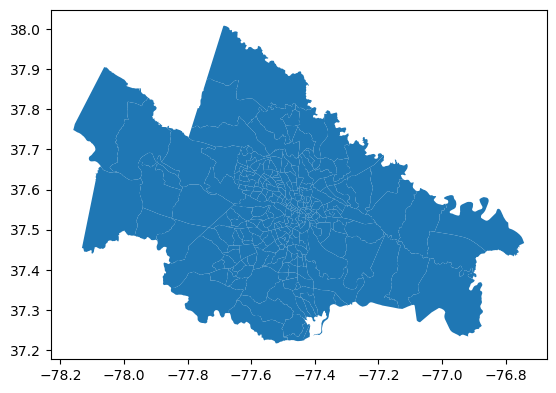

In [67]:
#find our region tracts - plot to ensure it looks right 
planrva_tracts = tracts(state = "VA", cb = True,
                    county = ["Charles City", "Chesterfield", "Goochland", "Henrico",
                              "Hanover", "New Kent", "Powhatan", "Richmond City"], 
                    year = 2021)
             
planrva_tracts.plot()
planrva_tracts.head()

C:\Users\egreenwell\AppData\Local\Temp\ipykernel_6688\3100973835.py:6: DeprecationWarning: ExtensionArray.fillna added a 'copy' keyword in pandas 2.1.0. In a future version, ExtensionArray subclasses will need to implement this keyword or an exception will be raised. In the interim, the keyword is ignored by GeometryArray.
  our_region.fillna(0, inplace = True)
c:\Users\egreenwell\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1436: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


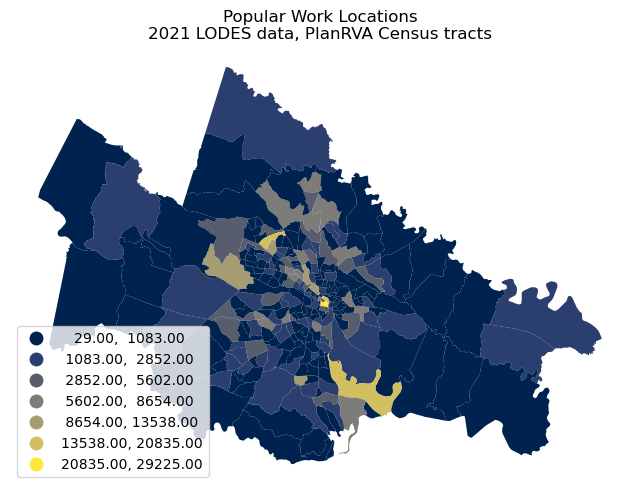

In [71]:
#join and make static figure

our_region = planrva_tracts.merge(geocode, left_on = "GEOID", right_on = "w_tract",
                             how = "left")

our_region.fillna(0, inplace = True)

our_region.plot(column = 'workers', legend = True, 
               cmap = "cividis", figsize = (8, 8), 
               k = 7, scheme = "naturalbreaks",
               legend_kwds = {"loc": "lower left"})

plt.title("Popular Work Locations\n2021 LODES data, PlanRVA Census tracts", fontsize = 12)

ax = plt.gca()

ax.set_axis_off()

plt.savefig(r'C:\GreenGIS\Slippy-LODES\region2.png')

In [70]:
our_region.head()

,STATEFP,COUNTYFP,TRACTCE,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,NAMELSADCO,STATE_NAME,LSAD,ALAND,AWATER,geometry,w_tract,workers
0,51,087,200404,1400000US51087200404,51087200404,2004.04,Census Tract 2004.04,VA,Henrico County,Virginia,CT,2144770,43191,"POLYGON ((-77.51815 37.60846, -77.51339 37.610...",51087200404,2600
1,51,760,020200,1400000US51760020200,51760020200,202,Census Tract 202,VA,Richmond city,Virginia,CT,1001402,0,"POLYGON ((-77.41410 37.54950, -77.41213 37.552...",51760020200,89
2,51,760,060900,1400000US51760060900,51760060900,609,Census Tract 609,VA,Richmond city,Virginia,CT,2792220,0,"POLYGON ((-77.45024 37.46060, -77.44869 37.469...",51760060900,1551
3,51,760,021200,1400000US51760021200,51760021200,212,Census Tract 212,VA,Richmond city,Virginia,CT,910277,0,"POLYGON ((-77.40888 37.51511, -77.40631 37.514...",51760021200,203
4,51,087,200134,1400000US51087200134,51087200134,2001.34,Census Tract 2001.34,VA,Henrico County,Virginia,CT,4590484,1335,"POLYGON ((-77.59825 37.59246, -77.59693 37.593...",51087200134,817
